In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import xtrack as xt
import xpart as xp
import xobjects as xo
import json
from pathlib import Path

In [ ]:
directory = Path("/eos/user/l/lpauwels/sps_simulations/MomentumAcceptance/tidp_bump_scan/studies_results/")
files = [f for f in directory.iterdir() if f.is_file()]

[PosixPath('/eos/user/l/lpauwels/sps_simulations/MomentumAcceptance/tidp_bump_scan/studies_results/bm10.0mm.json'), PosixPath('/eos/user/l/lpauwels/sps_simulations/MomentumAcceptance/tidp_bump_scan/studies_results/bm11.0mm.json'), PosixPath('/eos/user/l/lpauwels/sps_simulations/MomentumAcceptance/tidp_bump_scan/studies_results/bm12.0mm.json'), PosixPath('/eos/user/l/lpauwels/sps_simulations/MomentumAcceptance/tidp_bump_scan/studies_results/bm13.0mm.json'), PosixPath('/eos/user/l/lpauwels/sps_simulations/MomentumAcceptance/tidp_bump_scan/studies_results/bm14.0mm.json'), PosixPath('/eos/user/l/lpauwels/sps_simulations/MomentumAcceptance/tidp_bump_scan/studies_results/bm15.0mm.json'), PosixPath('/eos/user/l/lpauwels/sps_simulations/MomentumAcceptance/tidp_bump_scan/studies_results/bm16.0mm.json'), PosixPath('/eos/user/l/lpauwels/sps_simulations/MomentumAcceptance/tidp_bump_scan/studies_results/bm17.0mm.json'), PosixPath('/eos/user/l/lpauwels/sps_simulations/MomentumAcceptance/tidp_bump_sc

In [11]:
particles_dictionary = {}
context = xo.ContextCpu()
for file in files:
    bump_name = file.stem
    with open(file, 'r') as fid:
        particles_dictionary[bump_name] = json.load(fid)

In [12]:
bumps = list(particles_dictionary.keys())

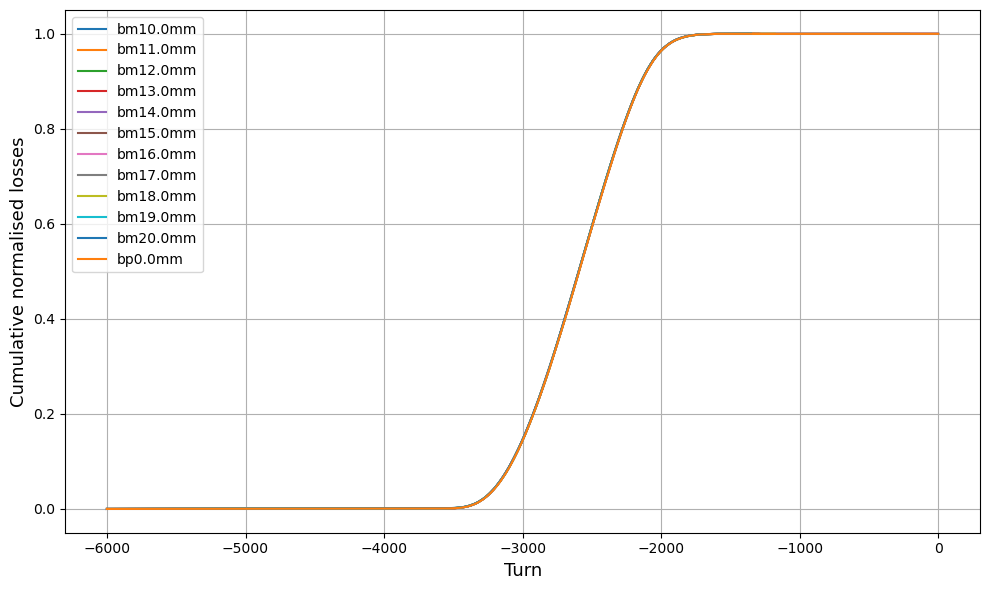

In [51]:
fig, ax = plt.subplots(1,1,figsize=(10,6))
max_particles = 1_000_000
for bump in bumps:
    turns, counts = np.unique(particles_dictionary[bump]['at_turn'], return_counts=True)
    ax.plot(- turns, 1 - np.cumsum(counts)/max_particles, label=bump)
ax.legend()
ax.grid()
ax.set_xlabel('Turn', fontsize=13)
ax.set_ylabel('Cumulative normalised losses', fontsize=13)
fig.tight_layout()
plt.savefig('Radial_steering_neg_bump.pdf', dpi=300)

In [38]:
reference = particles_dictionary[bumps[0]]['at_turn']

# Compare all others to the reference
for bump in bumps[1:]:
    if particles_dictionary[bump]['at_turn'] != reference:
        print(f"❌ {bump} is different from {bumps[0]}")
    else:
        print(f"✅ {bump} is identical")


❌ bm11.0mm is different from bm10.0mm
❌ bm12.0mm is different from bm10.0mm
❌ bm13.0mm is different from bm10.0mm
❌ bm14.0mm is different from bm10.0mm
❌ bm15.0mm is different from bm10.0mm
❌ bm16.0mm is different from bm10.0mm
❌ bm17.0mm is different from bm10.0mm
❌ bm18.0mm is different from bm10.0mm
❌ bm19.0mm is different from bm10.0mm
❌ bm20.0mm is different from bm10.0mm
❌ bp0.0mm is different from bm10.0mm


In [40]:
line = xt.Line.from_json('../../injection_lines/sps_with_aperture_inj_q20_beam_sagitta2.json')

Loading line from dict:   0%|          | 0/36395 [00:00<?, ?it/s]

Done loading line from dict.           


In [47]:
elems = []
for bump in bumps:
    elems_bump = np.unique(particles_dictionary[bump]['at_element'])
    for e in elems_bump:
        if e not in elems:
            elems.append(e)


In [49]:
for e in elems:
    print(line.element_names[e])

sps$start
vcak.12501.a_aper
bpcn.12508.a_aper
veqa.21910.a_aper
drift_1489..2
drift_1675..1
veqa.21910.b_aper
drift_1728..4


No one dies in the tidp, which explains the lack of effect of it ?